In [6]:
!git clone https://github.com/Varunsaxena16/Automatic-Road-Extraction-from-Sentinel-2-Imagery.git

Cloning into 'Automatic-Road-Extraction-from-Sentinel-2-Imagery'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 73 (delta 29), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 1.98 MiB | 12.24 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [7]:
%cd Automatic-Road-Extraction-from-Sentinel-2-Imagery

/content/Automatic-Road-Extraction-from-Sentinel-2-Imagery/Automatic-Road-Extraction-from-Sentinel-2-Imagery


In [8]:
!pip install -r requirements.txt

In [9]:
import sys
sys.path.append("src")

In [10]:
from src.preprocessing import load_geotiff, sanitize_image, minmax_normalize

tif_path = "data/south_delhi_aoi_s2.tif"

image, transform, crs, profile = load_geotiff(tif_path)

image = sanitize_image(image)
image = minmax_normalize(image)

In [13]:
import rasterio
from src.osm_mask import create_aoi_polygon, fetch_osm_roads, rasterize_roads

with rasterio.open(tif_path) as src:
    bounds = src.bounds
    transform = src.transform
    crs = src.crs
    height = src.height
    width = src.width

aoi_polygon_latlon = create_aoi_polygon(bounds, crs)

roads_gdf = fetch_osm_roads(aoi_polygon_latlon)

road_mask = rasterize_roads(
    roads_gdf,
    transform,
    crs,
    height,
    width
)

In [14]:
from src.segmentation import classical_road_segmentation

road_mask = classical_road_segmentation(image)

In [15]:
from src.postprocessing import refine_centerlines

centerlines = refine_centerlines(road_mask, min_length=40)

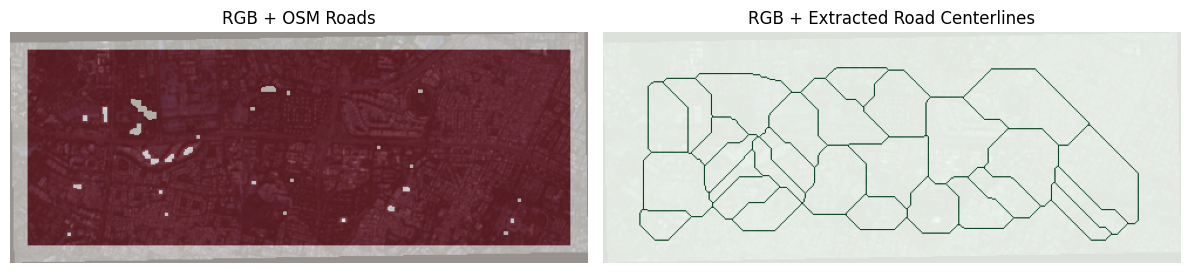

In [16]:
from src.visualization import overlay_osm_vs_extracted

overlay_osm_vs_extracted(
    image,
    road_mask,
    centerlines
)

In [17]:
from src.vectorization import vectorize_centerlines, export_geojson

gdf = vectorize_centerlines(
    centerlines,
    transform,
    crs,
    min_points=20
)

export_geojson(gdf, "outputs/extracted_centerlines.geojson")

gdf.head()

,geometry
0,"LINESTRING (715725 3162875, 715715 3162875, 71..."
1,"LINESTRING (716995 3162865, 716985 3162865, 71..."
2,"LINESTRING (715875 3162855, 715865 3162855, 71..."
3,"LINESTRING (714585 3162825, 714575 3162825, 71..."
4,"LINESTRING (714095 3162785, 714085 3162785, 71..."
